**TASK-3:IRIS FLOWER CLASSIFICATION**

**The Iris flower dataset consists of three species: setosa, versicolor,
and virginica. These species can be distinguished based on their
measurements. Now, imagine that you have the measurements
of Iris flowers categorized by their respective species. Your
objective is to train a machine learning model that can learn from
these measurements and accurately classify the Iris flowers into
their respective species.Use the Iris dataset to develop a model that can classify iris
flowers into different species based on their sepal and petal
measurements. This dataset is widely used for introductory
classification tasks.**

**Importing Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

**Loading Dataset**

In [5]:
df = pd.read_csv("IRIS.csv")
print(df.head())
print(df.shape)
print(df.info())

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


**Data Preprocessing**

In [9]:
df.fillna(df.mean(numeric_only=True), inplace=True)
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])
X = df.drop('species', axis=1)
y = df['species']

**Model Training**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Evaluation of Model**

In [16]:
accuracy = accuracy_score(y_test, y_pred)*100
print(f"Accuracy:{accuracy:.2f}%")
print(classification_report(y_test, y_pred))

Accuracy:90.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



**Visualization**

**i) Pie Chart**

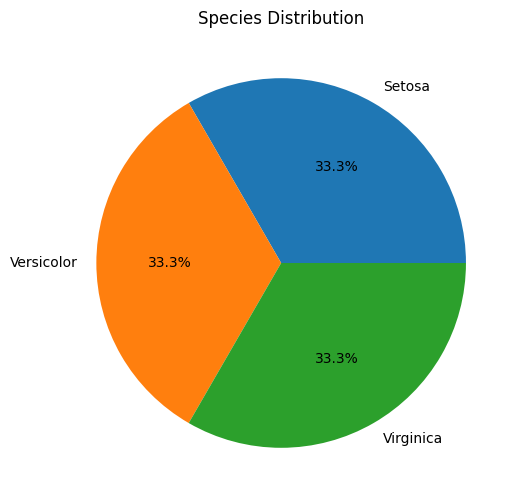

In [17]:
species_count = df['species'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    species_count,
    labels=['Setosa','Versicolor','Virginica'],
    autopct='%1.1f%%'
)

plt.title("Species Distribution")

plt.show()

**Correlation Heatmap**

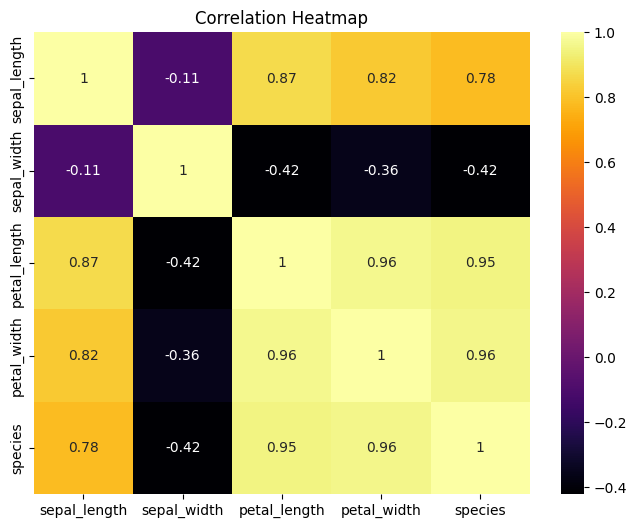

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='inferno'
)

plt.title("Correlation Heatmap")

plt.show()